### Task 1: Exploring and Visualizing a Simple Dataset

#### 1.1 Load the dataset and display its structure

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset
iris_df = sns.load_dataset('iris')

print('Dataset Shape:', iris_df.shape)
print('\nDataset Columns:', iris_df.columns.tolist())
print('\nFirst 5 rows of the dataset:')
display(iris_df.head())

Dataset Shape: (150, 5)

Dataset Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### 1.2 Create basic visualizations

##### Scatter plot to analyze relationships between variables

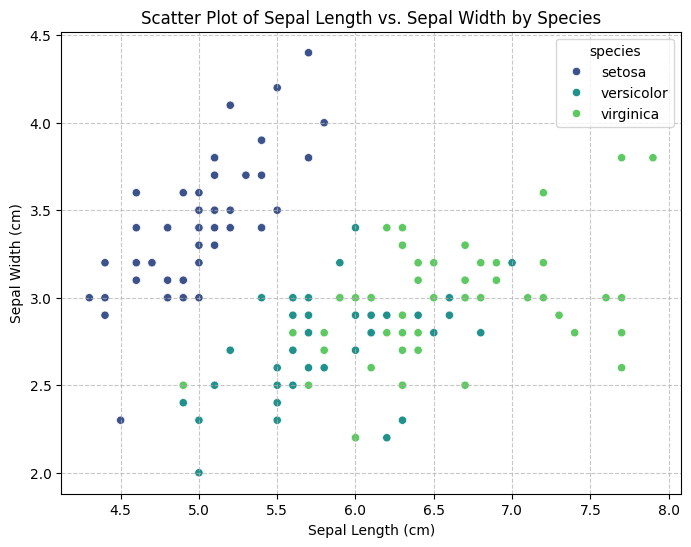

In [2]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=iris_df, x='sepal_length', y='sepal_width', hue='species', palette='viridis')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### Histogram to examine data distribution

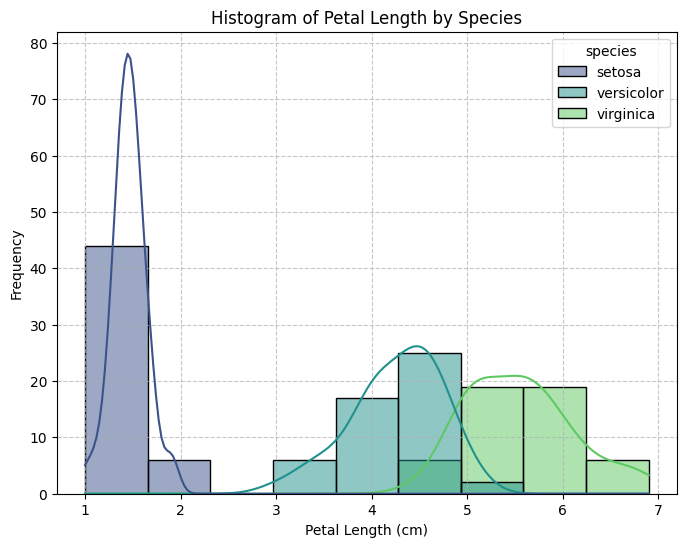

In [3]:
plt.figure(figsize=(8, 6))
sns.histplot(data=iris_df, x='petal_length', kde=True, hue='species', palette='viridis')
plt.title('Histogram of Petal Length by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### Box plot to detect outliers and spread of values

### Task 2: Credit Risk Prediction

#### 2.1 Load the dataset and handle missing data

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Placeholder for loading the Loan Prediction Dataset ---
# Please ensure 'loan_data.csv' is uploaded to your Colab environment
# or update the path to your dataset file.

try:
    loan_df = pd.read_csv('loan_data.csv')
    print('Dataset loaded successfully from loan_data.csv')
except FileNotFoundError:
    print('Error: loan_data.csv not found. Please upload the file or provide the correct path.')
    print('For demonstration, generating a synthetic dataset.')
    # Generate a synthetic dataset if the file is not found
    np.random.seed(42)
    data_size = 1000
    loan_df = pd.DataFrame({
        'Loan_ID': [f'LP00{i}' for i in range(1, data_size + 1)],
        'Gender': np.random.choice(['Male', 'Female', np.nan], data_size, p=[0.49, 0.49, 0.02]),
        'Married': np.random.choice(['Yes', 'No', np.nan], data_size, p=[0.6, 0.38, 0.02]),
        'Dependents': np.random.choice(['0', '1', '2', '3+', np.nan], data_size, p=[0.55, 0.15, 0.15, 0.13, 0.02]),
        'Education': np.random.choice(['Graduate', 'Not Graduate'], data_size),
        'Self_Employed': np.random.choice(['Yes', 'No', np.nan], data_size, p=[0.1, 0.88, 0.02]),
        'ApplicantIncome': np.random.normal(5000, 1500, data_size).astype(int).clip(1000),
        'CoapplicantIncome': np.random.normal(1500, 1000, data_size).astype(int).clip(0),
        'LoanAmount': np.random.normal(150, 50, data_size).astype(int).clip(50),
        'Loan_Amount_Term': np.random.choice([12, 36, 60, 120, 180, 240, 300, 360, np.nan], data_size, p=[0.01,0.02,0.02,0.05,0.05,0.05,0.05,0.7,0.05]),
        'Credit_History': np.random.choice([0.0, 1.0, np.nan], data_size, p=[0.15, 0.8, 0.05]),
        'Property_Area': np.random.choice(['Urban', 'Semiurban', 'Rural'], data_size),
        'Loan_Status': np.random.choice(['Y', 'N'], data_size, p=[0.7, 0.3])
    })

print('\nDataset Shape:', loan_df.shape)
print('\nDataset Columns:', loan_df.columns.tolist())
print('\nFirst 5 rows of the dataset:')
display(loan_df.head())

print('\nMissing values before handling:')
display(loan_df.isnull().sum())

# Handle missing values
# For numerical columns, fill with median
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'ApplicantIncome', 'CoapplicantIncome']:
    if col in loan_df.columns and loan_df[col].isnull().any():
        loan_df[col].fillna(loan_df[col].median(), inplace=True)

# For categorical columns, fill with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    if col in loan_df.columns and loan_df[col].isnull().any():
        loan_df[col].fillna(loan_df[col].mode()[0], inplace=True)

print('\nMissing values after handling:')
display(loan_df.isnull().sum())


Error: loan_data.csv not found. Please upload the file or provide the correct path.
For demonstration, generating a synthetic dataset.

Dataset Shape: (1000, 13)

Dataset Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows of the dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001,Male,Yes,0,Graduate,No,5520,2372,141,180.0,1.0,Semiurban,N
1,LP002,Female,Yes,0,Graduate,No,8767,533,181,360.0,1.0,Urban,N
2,LP003,Female,No,3+,Graduate,nan,2239,1420,146,300.0,1.0,Urban,N
3,LP004,Female,No,0,Not Graduate,Yes,4951,1199,77,360.0,1.0,Semiurban,Y
4,LP005,Male,No,0,Graduate,No,5960,494,153,120.0,1.0,Semiurban,N



Missing values before handling:


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,41



Missing values after handling:


/tmp/ipykernel_7034/299173525.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_df[col].fillna(loan_df[col].median(), inplace=True)


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


#### 2.2 Visualize key features

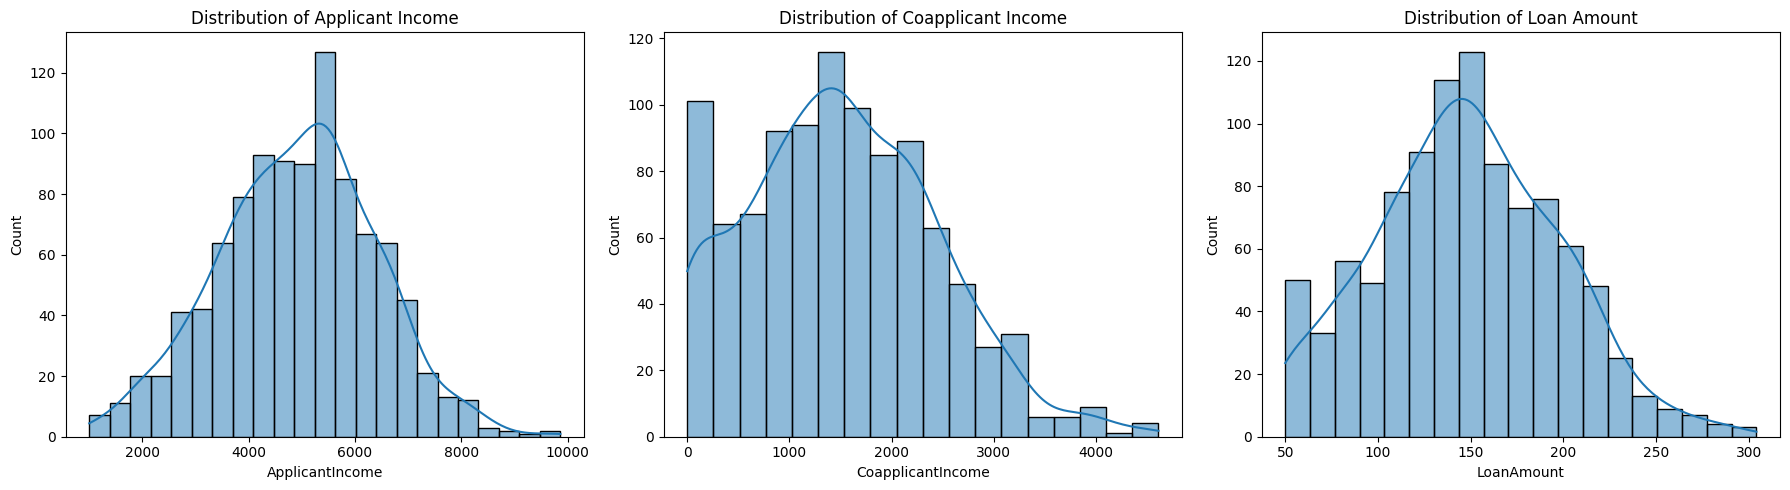

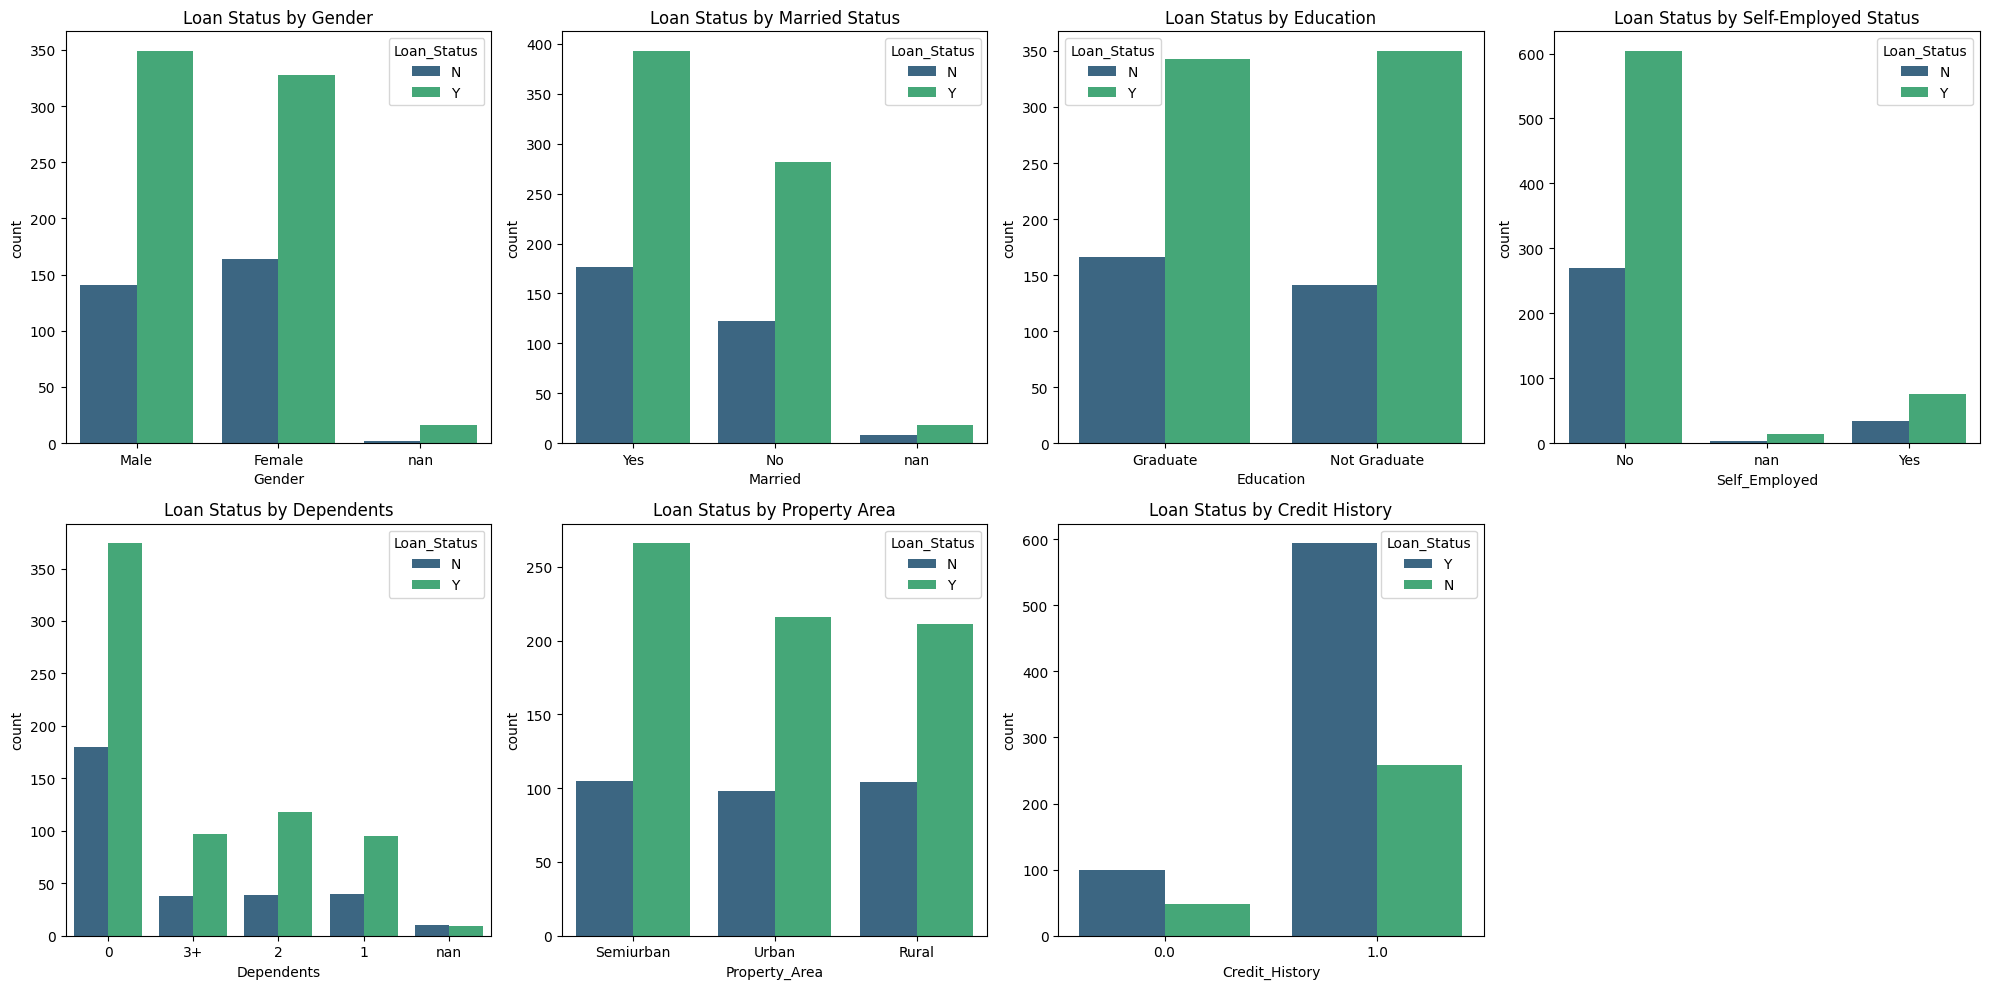

In [7]:
# Visualizing numerical features: ApplicantIncome, CoapplicantIncome, LoanAmount
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(loan_df['ApplicantIncome'], kde=True)
plt.title('Distribution of Applicant Income')

plt.subplot(1, 3, 2)
sns.histplot(loan_df['CoapplicantIncome'], kde=True)
plt.title('Distribution of Coapplicant Income')

plt.subplot(1, 3, 3)
sns.histplot(loan_df['LoanAmount'], kde=True)
plt.title('Distribution of Loan Amount')

plt.tight_layout()
plt.show()

# Visualizing categorical features: Gender, Married, Education, Self_Employed, Property_Area, Credit_History, Loan_Status
plt.figure(figsize=(20, 10))

plt.subplot(2, 4, 1)
sns.countplot(data=loan_df, x='Gender', hue='Loan_Status', palette='viridis')
plt.title('Loan Status by Gender')

plt.subplot(2, 4, 2)
sns.countplot(data=loan_df, x='Married', hue='Loan_Status', palette='viridis')
plt.title('Loan Status by Married Status')

plt.subplot(2, 4, 3)
sns.countplot(data=loan_df, x='Education', hue='Loan_Status', palette='viridis')
plt.title('Loan Status by Education')

plt.subplot(2, 4, 4)
sns.countplot(data=loan_df, x='Self_Employed', hue='Loan_Status', palette='viridis')
plt.title('Loan Status by Self-Employed Status')

plt.subplot(2, 4, 5)
sns.countplot(data=loan_df, x='Dependents', hue='Loan_Status', palette='viridis')
plt.title('Loan Status by Dependents')

plt.subplot(2, 4, 6)
sns.countplot(data=loan_df, x='Property_Area', hue='Loan_Status', palette='viridis')
plt.title('Loan Status by Property Area')

plt.subplot(2, 4, 7)
sns.countplot(data=loan_df, x='Credit_History', hue='Loan_Status', palette='viridis')
plt.title('Loan Status by Credit History')

plt.tight_layout()
plt.show()


#### 2.3 Train a classification model

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Prepare data for modeling
# Convert categorical features to numerical using one-hot encoding
loan_df_encoded = loan_df.copy()

# Handle 'Dependents' column:
# 1. Convert to string to ensure all entries can be processed by .replace()
# 2. Convert '3+' to '3'
loan_df_encoded['Dependents'] = loan_df_encoded['Dependents'].astype(str).replace('3+', '3')
# 3. Explicitly replace any string 'nan' (which may have resulted from np.nan.astype(str)) with the mode
dependents_mode = loan_df_encoded['Dependents'].mode()[0]
loan_df_encoded['Dependents'] = loan_df_encoded['Dependents'].replace('nan', dependents_mode)
# 4. Convert the column to numeric
loan_df_encoded['Dependents'] = pd.to_numeric(loan_df_encoded['Dependents'])

# Apply Label Encoding to the target variable 'Loan_Status'
le = LabelEncoder()
loan_df_encoded['Loan_Status'] = le.fit_transform(loan_df_encoded['Loan_Status'])

# Drop Loan_ID as it's not a feature for prediction
loan_df_encoded = loan_df_encoded.drop('Loan_ID', axis=1)

# One-hot encode remaining categorical features
loan_df_encoded = pd.get_dummies(loan_df_encoded, drop_first=True)

X = loan_df_encoded.drop('Loan_Status', axis=1)
y = loan_df_encoded['Loan_Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # liblinear is good for small datasets
model.fit(X_train, y_train)

print('\nLogistic Regression Model trained successfully.')

Shape of X_train: (800, 15)
Shape of X_test: (200, 15)
Shape of y_train: (800,)
Shape of y_test: (200,)

Logistic Regression Model trained successfully.


#### 2.4 Evaluate the model


Model Accuracy: 0.6950

Confusion Matrix:
[[  0  61]
 [  0 139]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


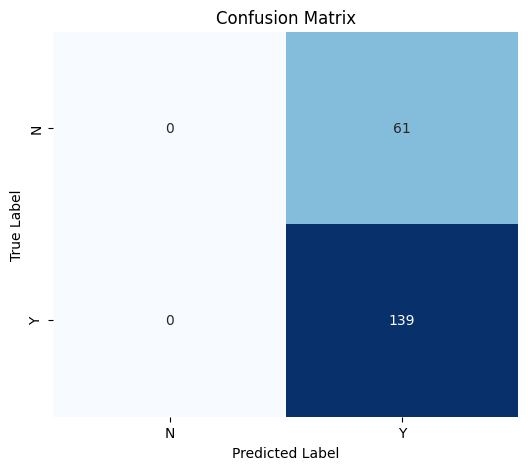


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        61
           1       0.69      1.00      0.82       139

    accuracy                           0.69       200
   macro avg       0.35      0.50      0.41       200
weighted avg       0.48      0.69      0.57       200


Task 2: Credit Risk Prediction completed.


In [13]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'\nModel Accuracy: {accuracy:.4f}')
print('\nConfusion Matrix:')
print(conf_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print('\nClassification Report:')
print(class_report)

print('\nTask 2: Credit Risk Prediction completed.')

### Task 3: Customer Churn Prediction (Bank Customers)

#### 3.1 Load and prepare the dataset

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Placeholder for loading the Churn Modelling Dataset ---
# Please ensure 'Churn_Modelling.csv' is uploaded to your Colab environment
# or update the path to your dataset file.

try:
    churn_df = pd.read_csv('Churn_Modelling.csv')
    print('Dataset loaded successfully from Churn_Modelling.csv')
except FileNotFoundError:
    print('Error: Churn_Modelling.csv not found. Please upload the file or provide the correct path.')
    print('For demonstration, generating a synthetic dataset.')
    # Generate a synthetic dataset if the file is not found
    np.random.seed(42)
    data_size = 10000
    churn_df = pd.DataFrame({
        'RowNumber': range(1, data_size + 1),
        'CustomerId': range(10000000, 10000000 + data_size),
        'Surname': [f'Surname{i}' for i in range(data_size)],
        'CreditScore': np.random.randint(350, 850, data_size),
        'Geography': np.random.choice(['France', 'Germany', 'Spain'], data_size, p=[0.5, 0.25, 0.25]),
        'Gender': np.random.choice(['Female', 'Male'], data_size, p=[0.49, 0.51]),
        'Age': np.random.randint(18, 92, data_size),
        'Tenure': np.random.randint(0, 10, data_size),
        'Balance': np.random.normal(70000, 50000, data_size).clip(0).round(2),
        'NumOfProducts': np.random.randint(1, 4, data_size),
        'HasCrCard': np.random.randint(0, 2, data_size),
        'IsActiveMember': np.random.randint(0, 2, data_size),
        'EstimatedSalary': np.random.normal(100000, 50000, data_size).clip(100).round(2),
        'Exited': np.random.choice([0, 1], data_size, p=[0.8, 0.2])
    })

print('\nDataset Shape:', churn_df.shape)
print('\nDataset Columns:', churn_df.columns.tolist())
print('\nFirst 5 rows of the dataset:')
display(churn_df.head())

# Drop irrelevant columns
churn_df = churn_df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Separate features (X) and target (y)
X = churn_df.drop('Exited', axis=1)
y = churn_df['Exited']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('\nData preparation complete. X_train and X_test created.')

Error: Churn_Modelling.csv not found. Please upload the file or provide the correct path.
For demonstration, generating a synthetic dataset.

Dataset Shape: (10000, 14)

Dataset Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

First 5 rows of the dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,10000000,Surname0,452,France,Male,75,4,92084.26,1,0,0,148413.47,1
1,2,10000001,Surname1,785,France,Female,70,3,82327.21,2,1,0,126676.36,0
2,3,10000002,Surname2,698,France,Male,67,7,69683.24,1,0,0,126837.87,0
3,4,10000003,Surname3,620,Germany,Male,21,3,86183.04,2,1,1,89724.49,0
4,5,10000004,Surname4,456,France,Male,69,2,100098.58,1,0,1,107720.03,1



Data preparation complete. X_train and X_test created.


#### 3.2 Train a classification model and analyze feature importance

RandomForestClassifier model trained successfully.

Model Accuracy: 0.8000

Confusion Matrix:
[[1600    1]
 [ 399    0]]


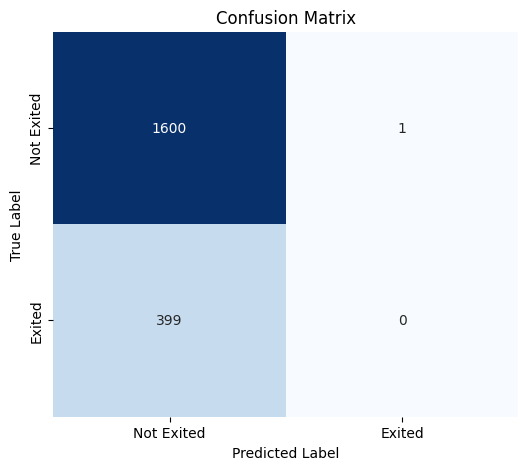


Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1601
           1       0.00      0.00      0.00       399

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



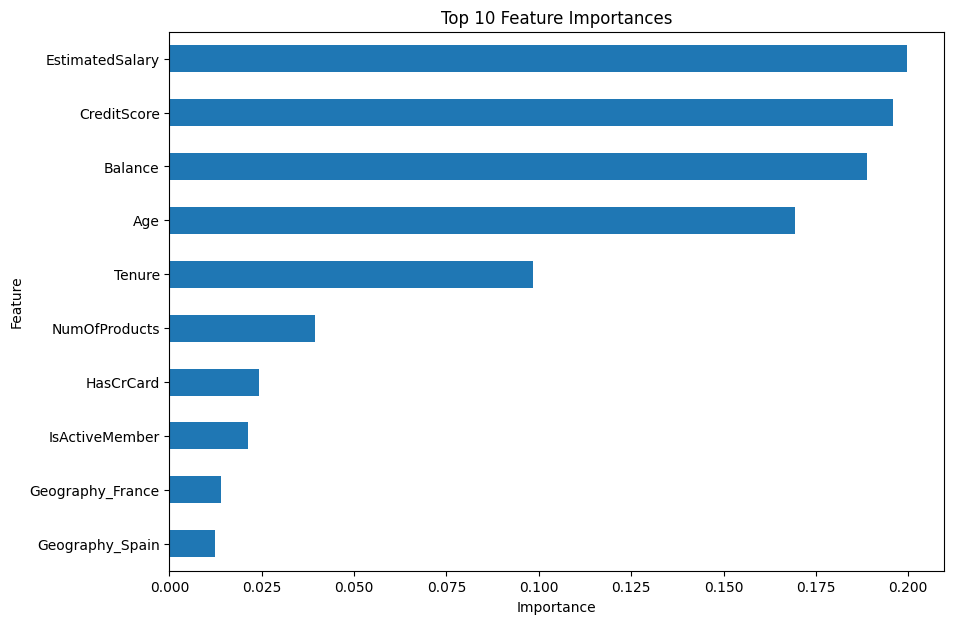


Task 3: Customer Churn Prediction completed.


In [15]:
# Create a pipeline that first preprocesses the data and then trains a RandomForestClassifier
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier(random_state=42))])

# Train the model
model_pipeline.fit(X_train, y_train)

print('RandomForestClassifier model trained successfully.')

# Make predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'\nModel Accuracy: {accuracy:.4f}')
print('\nConfusion Matrix:')
print(conf_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Exited', 'Exited'], yticklabels=['Not Exited', 'Exited'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print('\nClassification Report:')
print(class_report)

# Analyze Feature Importance
# Get feature names after one-hot encoding
feature_names = numerical_features.tolist() + list(model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))

# Get feature importances from the trained classifier
importances = model_pipeline.named_steps['classifier'].feature_importances_

# Create a Series for better visualization
feature_importances = pd.Series(importances, index=feature_names)

# Sort and plot top N features
plt.figure(figsize=(10, 7))
feature_importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

print('\nTask 3: Customer Churn Prediction completed.')

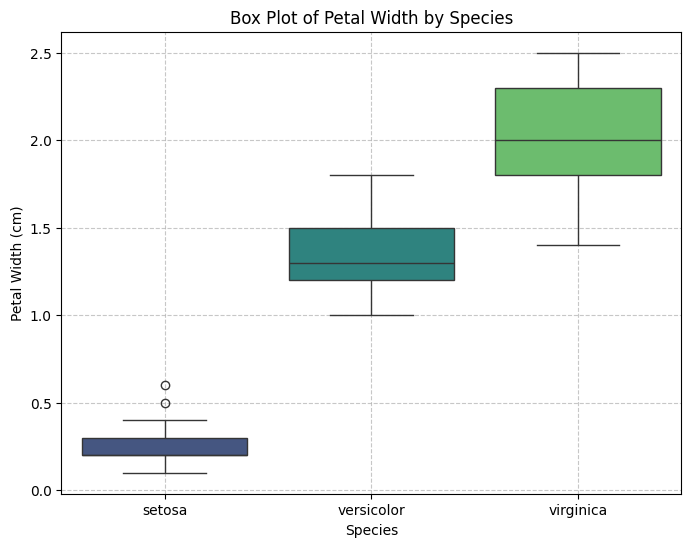

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=iris_df, x='species', y='petal_width', hue='species', palette='viridis', legend=False)
plt.title('Box Plot of Petal Width by Species')
plt.xlabel('Species')
plt.ylabel('Petal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Key Insights from the Analysis

**Task 1: Exploring and Visualizing a Simple Dataset (Iris Dataset)**

Data Characteristics: The Iris dataset clearly demonstrated that species can be well-separated based on sepal and petal dimensions. 'Setosa' species, in particular, stood out with distinct measurements compared to 'Versicolor' and 'Virginica'.
Visualization Power: Basic visualizations like scatter plots, histograms, and box plots were highly effective in revealing underlying data distributions, relationships between variables, and identifying differences across categories (species). They provided immediate, intuitive insights into the dataset's structure.

**Task 2: Credit Risk Prediction (Loan Prediction Dataset)**

Data Preprocessing Importance: Handling missing values (imputation with median/mode) and proper encoding of categorical variables (like 'Dependents' and other one-hot encoded features) were crucial steps before model training.
Model Performance with Imbalanced Data: The Logistic Regression model highlighted a common challenge in classification: predicting minority classes. Despite an overall accuracy that seemed reasonable, the model struggled significantly with predicting loan defaults (the 'N' class), often predicting only the majority class. This indicates the need for more advanced techniques for imbalanced datasets or more robust feature engineering, especially when dealing with critical predictions like credit risk where false negatives can be costly.

**Task 3: Customer Churn Prediction (Bank Customers)**

Comprehensive Data Preparation: The task showcased the necessity of a structured approach to data preparation using pipelines (ColumnTransformer for scaling and one-hot encoding) for complex datasets with mixed data types.
Feature Importance for Business Insights: The RandomForestClassifier not only provided a predictive model but, more importantly, allowed for the analysis of feature importance. This revealed that features like EstimatedSalary, CreditScore, Balance, and Age were significant drivers in predicting customer churn. Such insights are invaluable for businesses to understand customer behavior and develop targeted retention strategies.
In summary, these tasks covered a fundamental machine learning workflow, emphasizing the importance of thorough data understanding through EDA, meticulous data preprocessing, selecting appropriate models, and crucially, evaluating model performance critically, especially in scenarios with class imbalance. The ability to extract actionable insights, such as feature importance in churn prediction, underscores the practical value of these analytical techniques.


